In [1]:
from getpass import getpass
import os

token = getpass("GitHub Token: ")
os.environ["GITHUB_TOKEN"] = token


GitHub Token: ··········


In [2]:
%cd /content
%rm -rf ddpm_option_pricing
!git clone https://${GITHUB_TOKEN}@github.com/nilay47/ddpm_option_pricing.git
%cd ddpm_option_pricing

/content
Cloning into 'ddpm_option_pricing'...
remote: Enumerating objects: 59, done.
remote: Counting objects: 100% (59/59), done.
remote: Compressing objects: 100% (43/43), done.
remote: Total 59 (delta 30), reused 40 (delta 14), pack-reused 0 (from 0)
Receiving objects: 100% (59/59), 133.46 KiB | 1.07 MiB/s, done.
Resolving deltas: 100% (30/30), done.
/content/ddpm_option_pricing


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

from src.experiments import (
    price_vanilla_with_ddpm,
    ddpm_multistrike_with_iv,
    ddpm_multistrike_ablation_shift,
)

# Basic config (adjust to your experiment)
S0 = 100.0       # spot for experiments
K0 = 100.0       # central strike
r = 0.05
sigma = 0.2
mu = 0.08

H_steps = 21
dt = 1.0 / 252.0
T_total = H_steps * dt
n_paths = 1_000

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cuda


In [4]:
import torch
import numpy as np
import math

from src.schedules import make_alpha_schedule
from src.ddpm_model import ScoreMLP
from src.train_ddpm import train_ddpm
from src.sample_ddpm import sample_returns_Q_std
from src.price_options import price_vanilla_with_ddpm


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

S0 = 100.0
mu = 0.08
sigma = 0.20
r = 0.04
days_per_year = 252
dt = 1.0 / days_per_year

N_train = 1_000
T = 1000  # diffusion steps

v0 = sigma**2 * dt
s0 = math.sqrt(v0)
mP = (mu - 0.5 * sigma**2) * dt

rng = np.random.default_rng(42)
torch.manual_seed(42)
np.random.seed(42)

# THIS is the important part:
y_train = rng.normal(loc=mP, scale=s0, size=(N_train,)).astype(np.float32)
y_train_std = (y_train - mP) / s0



In [6]:
from torch.utils.data import TensorDataset, DataLoader
train_loader = DataLoader(TensorDataset(torch.from_numpy(y_train_std).unsqueeze(1)),
                          batch_size=512, shuffle=True)


In [7]:
betas, alphas, alphas_bar = make_alpha_schedule(T, device)


In [8]:
model = ScoreMLP(hidden_dim=256, time_emb_dim=64).to(device)

model = train_ddpm(
    model=model,
    train_loader=train_loader,
    alphas_bar=alphas_bar,
    T=T,
    device=device,
    epochs=60
)


Epoch 1/60:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 2/60:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 3/60:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 4/60:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 5/60:   0%|          | 0/2 [00:00<?, ?it/s]

...

Epoch 56/60:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 57/60:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 58/60:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 59/60:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 60/60:   0%|          | 0/2 [00:00<?, ?it/s]

In [9]:
@torch.no_grad()
def p_check_bias_scale(model, n=1000):
    model.eval()
    B = n
    y = torch.randn(B, 1, device=device)
    for t in reversed(range(T)):
        a_bar_t = alphas_bar[t]
        t01 = torch.full((B,), (t + 0.5)/T, device=device)
        eps_hat = model(y, t01)
        if t > 0:
            post_var = (1 - alphas_bar[t-1]) / (1 - a_bar_t) * betas[t]
            post_var = torch.clamp(post_var, min=1e-12)
            mean = (1 / torch.sqrt(alphas[t])) * (
                y - (betas[t] / torch.sqrt(1 - a_bar_t)) * eps_hat
            )
            y = mean + torch.sqrt(post_var) * torch.randn_like(y)
        else:
            y = (1 / torch.sqrt(alphas[t])) * (
                y - (betas[t] / torch.sqrt(1 - a_bar_t)) * eps_hat
            )
    y_std = y.view(-1).cpu().numpy()
    return float(y_std.mean()), float(y_std.std(ddof=1))

m_hat_P, s_hat_P = p_check_bias_scale(model)
print(m_hat_P, s_hat_P)


0.03980404511094093 0.9734224677085876


In [10]:
res_single = price_vanilla_with_ddpm(
    model=model,
    S0=S0,
    K=K0,
    r=r,
    sigma=sigma,
    mu=mu,
    H_steps=H_steps,
    n_paths=n_paths,
    alphas=alphas,
    alphas_bar=alphas_bar,
    betas=betas,
    m_hat_P=m_hat_P,
    s_hat_P=s_hat_P,
    dt=dt,
    device=device,
    use_ddim=False,
    n_ddim_steps=250,
    checkpoints=(21, 63, 126, 252),
    option_type="call",
)

res_single


{'P_m_hat': 0.03980404511094093,
 'P_s_hat': 0.9734224677085876,
 'returns_mean': 7.93649596744217e-05,
 'returns_std': 0.012329019606113434,
 'martingale': {21: np.float64(99.98948573464128)},
 'ks_stat': 0.022655771442009143,
 'ks_pvalue': 0.6749909625114692,
 'ddpm_price': np.float64(2.4088000701985406),
 'ddpm_stderr': np.float64(0.11087687227538674),
 'bs_price': np.float64(2.4693615361246657),
 'abs_diff': 0.0605614659261251}

In [11]:
strikes = np.linspace(0.8 * S0, 1.2 * S0, 7)

df_iv = ddpm_multistrike_with_iv(
    model=model,
    S0=S0,
    strikes=strikes,
    r=r,
    sigma=sigma,
    mu=mu,
    H_steps=H_steps,
    n_paths=n_paths,
    alphas=alphas,
    alphas_bar=alphas_bar,
    betas=betas,
    m_hat_P=m_hat_P,
    s_hat_P=s_hat_P,
    dt=dt,
    device=device,
    option_type="call",
    use_ddim=False,
    n_ddim_steps=250,
)

df_iv


,strike,ddpm_price,ddpm_stderr,gbm_price,gbm_stderr,bs_price,iv_ddpm,iv_gbm,iv_bs
0,80.000000,20.251211,0.174832,20.407633,0.187805,20.266274,NaN,0.426293,0.2
1,86.666667,13.611842,0.174376,13.543389,0.179730,13.631342,NaN,NaN,0.2
2,93.333333,7.168543,0.164063,7.245572,0.166950,7.257270,0.181007,0.197669,0.2
3,100.000000,2.344782,0.111159,2.352423,0.107123,2.469362,0.189141,0.189807,0.2
4,106.666667,0.409891,0.048855,0.432528,0.046689,0.441634,0.195245,0.198649,0.2
5,113.333333,0.044758,0.014303,0.040043,0.012124,0.038578,0.204457,0.201096,0.2
6,120.000000,0.001850,0.001368,0.004885,0.002840,0.001686,0.201533,0.219648,0.2


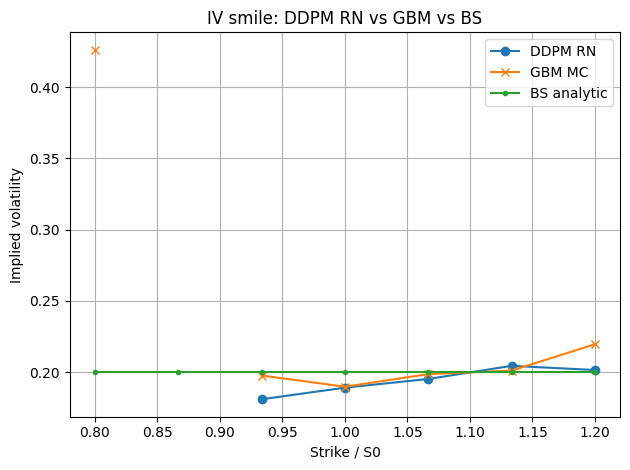

In [12]:
moneyness = df_iv["strike"].values / S0

plt.figure()
plt.plot(moneyness, df_iv["iv_ddpm"], marker="o", label="DDPM RN")
plt.plot(moneyness, df_iv["iv_gbm"], marker="x", label="GBM MC")
plt.plot(moneyness, df_iv["iv_bs"], marker=".", label="BS analytic")
plt.xlabel("Strike / S0")
plt.ylabel("Implied volatility")
plt.title("IV smile: DDPM RN vs GBM vs BS")
plt.grid(True)
plt.legend()
plt.tight_layout()


In [13]:
df_ablation = ddpm_multistrike_ablation_shift(
    model=model,
    S0=S0,
    strikes=strikes,
    r=r,
    sigma=sigma,
    mu=mu,
    H_steps=H_steps,
    n_paths=n_paths,
    alphas=alphas,
    alphas_bar=alphas_bar,
    betas=betas,
    m_hat_P=m_hat_P,
    s_hat_P=s_hat_P,
    dt=dt,
    device=device,
    option_type="call",
    use_ddim=False,
    n_ddim_steps=250,
)

df_ablation


,strike,price_shift,stderr_shift,price_noshift,stderr_noshift
0,80.000000,20.259934,0.179085,20.606157,0.187556
1,86.666667,13.631360,0.177663,13.967171,0.187124
2,93.333333,7.248947,0.163617,7.537933,0.176073
3,100.000000,2.409280,0.110392,2.669804,0.125608
4,106.666667,0.389466,0.045750,0.582843,0.060160
5,113.333333,0.031650,0.015558,0.083601,0.019850
6,120.000000,0.007423,0.007423,0.003377,0.002383


In [14]:
import math
from typing import Dict, Tuple, Optional, Sequence

def martingale_trajectory(
    returns_Q: np.ndarray,
    S0: float,
    r: float,
    dt: float,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Full martingale trajectory:
        M_t = e^{-rt} E_Q[S_t]
    for t = 0,1,...,H_steps.

    Args:
        returns_Q: (n_paths, H_steps) log-returns.
        S0: spot.
        r: risk free rate.
        dt: time step.

    Returns:
        times: shape (H_steps+1,), in years.
        M:     shape (H_steps+1,), discounted expected prices.
    """
    if returns_Q.ndim != 2:
        raise ValueError(f"returns_Q must have shape (n_paths, H_steps), got {returns_Q.shape}")

    n_paths, H_steps = returns_Q.shape
    S = np.full((n_paths,), S0, dtype=np.float64)

    times = [0.0]
    M = [S0]  # at t = 0, e^{-0} E[S0] = S0

    for t in range(1, H_steps + 1):
        S *= np.exp(returns_Q[:, t - 1])
        tau = t * dt
        disc = math.exp(-r * tau)
        M.append(disc * S.mean())
        times.append(tau)

    return np.array(times), np.array(M)


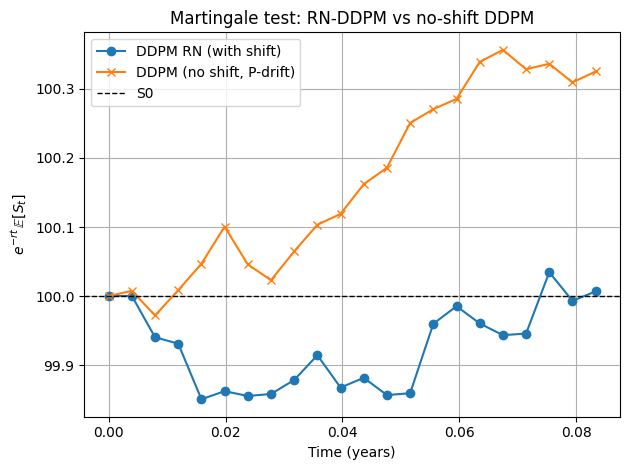

In [15]:
from src.sample_ddpm import sample_returns_Q_std
#from src.experiments import martingale_trajectory

# --- sample RN returns (with epsilon shift) ---
returns_Q = sample_returns_Q_std(
    model=model,
    n_paths=n_paths,
    H_steps=H_steps,
    mu=mu,
    r=r,                  # RN drift
    sigma=sigma,
    dt=dt,
    alphas=alphas,
    alphas_bar=alphas_bar,
    betas=betas,
    m_hat=m_hat_P,
    s_hat=s_hat_P,
    s0=math.sqrt(sigma**2 * dt),
    T=alphas_bar.shape[0],
    device=device,
    use_ddim=False,
    n_ddim_steps=250,
)

# --- sample "no-shift" returns (physical measure, r = mu) ---
returns_P = sample_returns_Q_std(
    model=model,
    n_paths=n_paths,
    H_steps=H_steps,
    mu=mu,
    r=mu,                  # r = mu → dm_std = 0 → no epsilon shift
    sigma=sigma,
    dt=dt,
    alphas=alphas,
    alphas_bar=alphas_bar,
    betas=betas,
    m_hat=m_hat_P,
    s_hat=s_hat_P,
    s0=math.sqrt(sigma**2 * dt),
    T=alphas_bar.shape[0],
    device=device,
    use_ddim=False,
    n_ddim_steps=250,
)

# --- compute martingale trajectories ---
t_Q, M_Q = martingale_trajectory(returns_Q, S0=S0, r=r, dt=dt)
t_P, M_P = martingale_trajectory(returns_P, S0=S0, r=r, dt=dt)

# --- plot ---
plt.figure()
plt.plot(t_Q, M_Q, marker="o", label="DDPM RN (with shift)")
plt.plot(t_P, M_P, marker="x", label="DDPM (no shift, P-drift)")
plt.axhline(S0, linestyle="--", color="k", linewidth=1, label="S0")
plt.xlabel("Time (years)")
plt.ylabel(r"$e^{-rt}\,\mathbb{E}[S_t]$")
plt.title("Martingale test: RN-DDPM vs no-shift DDPM")
plt.grid(True)
plt.legend()
plt.tight_layout()


In [16]:
mu_big = 0.15
r_small = 0.01
H_steps_long = 63
T_total_long = H_steps_long * dt

n_paths_long = 1_000
strikes = np.linspace(0.8 * S0, 1.2 * S0, 7)


In [17]:
from src.experiments import ddpm_multistrike_with_iv, ddpm_multistrike_ablation_shift

df_iv_big = ddpm_multistrike_with_iv(
    model=model,
    S0=S0,
    strikes=strikes,
    r=r_small,
    sigma=sigma,
    mu=mu_big,
    H_steps=H_steps_long,
    n_paths=n_paths_long,
    alphas=alphas,
    alphas_bar=alphas_bar,
    betas=betas,
    m_hat_P=m_hat_P,
    s_hat_P=s_hat_P,
    dt=dt,
    device=device,
    option_type="call",
    use_ddim=False,
    n_ddim_steps=250,
)

df_iv_big


,strike,ddpm_price,ddpm_stderr,gbm_price,gbm_stderr,bs_price,iv_ddpm,iv_gbm,iv_bs
0,80.000000,20.201698,0.312631,19.892197,0.321623,20.236844,0.146958,NaN,0.2
1,86.666667,13.798671,0.299740,14.080374,0.304342,13.850468,0.191546,0.230991,0.2
2,93.333333,8.204606,0.260325,8.401000,0.269530,8.242856,0.197422,0.210489,0.2
3,100.000000,4.058727,0.197605,4.026482,0.200801,4.108870,0.197479,0.195858,0.2
4,106.666667,1.666061,0.127841,1.556172,0.118640,1.681767,0.199073,0.192536,0.2
5,113.333333,0.529550,0.072704,0.532160,0.068947,0.564173,0.196485,0.196753,0.2
6,120.000000,0.148692,0.039593,0.168822,0.043110,0.156739,0.198112,0.202732,0.2


In [18]:
df_ablation_big = ddpm_multistrike_ablation_shift(
    model=model,
    S0=S0,
    strikes=strikes,
    r=r_small,
    sigma=sigma,
    mu=mu_big,
    H_steps=H_steps_long,
    n_paths=n_paths_long,
    alphas=alphas,
    alphas_bar=alphas_bar,
    betas=betas,
    m_hat_P=m_hat_P,
    s_hat_P=s_hat_P,
    dt=dt,
    device=device,
    option_type="call",
    use_ddim=False,
    n_ddim_steps=250,
)

df_ablation_big


,strike,price_shift,stderr_shift,price_noshift,stderr_noshift
0,80.000000,20.203897,0.308475,23.732945,0.311197
1,86.666667,13.772078,0.297022,17.199217,0.303785
2,93.333333,8.145874,0.259025,11.102460,0.278091
3,100.000000,4.034603,0.194713,6.058248,0.226420
4,106.666667,1.629671,0.125376,2.673257,0.158119
5,113.333333,0.541454,0.067900,0.940244,0.092647
6,120.000000,0.123016,0.031630,0.236659,0.049876


In [19]:
df = pd.merge(df_iv_big, df_ablation_big, on = 'strike')
df

,strike,ddpm_price,ddpm_stderr,gbm_price,gbm_stderr,bs_price,iv_ddpm,iv_gbm,iv_bs,price_shift,stderr_shift,price_noshift,stderr_noshift
0,80.000000,20.201698,0.312631,19.892197,0.321623,20.236844,0.146958,NaN,0.2,20.203897,0.308475,23.732945,0.311197
1,86.666667,13.798671,0.299740,14.080374,0.304342,13.850468,0.191546,0.230991,0.2,13.772078,0.297022,17.199217,0.303785
2,93.333333,8.204606,0.260325,8.401000,0.269530,8.242856,0.197422,0.210489,0.2,8.145874,0.259025,11.102460,0.278091
3,100.000000,4.058727,0.197605,4.026482,0.200801,4.108870,0.197479,0.195858,0.2,4.034603,0.194713,6.058248,0.226420
4,106.666667,1.666061,0.127841,1.556172,0.118640,1.681767,0.199073,0.192536,0.2,1.629671,0.125376,2.673257,0.158119
5,113.333333,0.529550,0.072704,0.532160,0.068947,0.564173,0.196485,0.196753,0.2,0.541454,0.067900,0.940244,0.092647
6,120.000000,0.148692,0.039593,0.168822,0.043110,0.156739,0.198112,0.202732,0.2,0.123016,0.031630,0.236659,0.049876


In [20]:
# Asian option experiment imports
from src.price_asian_options import price_asian_with_ddpm
import pandas as pd
from pathlib import Path

#############################


# Configuration for Asian option experiments

print("S0:", S0, "r:", r, "sigma:", sigma, "mu:", mu, "dt:", dt)

# Number of monitoring steps (in trading days)
asian_H_list = [21, 63, 126]   # approx 1m, 3m, 6m if dt = 1/252

# Strikes as multiples of S0
strike_multipliers = [0.9, 1.0, 1.1]

# Monte Carlo paths per Asian run
n_paths_asian = 1000

# Checkpoints for martingale checks
asian_checkpoints = [21, 63, 126, 252]

option_type = "call"
include_S0_in_average = False     # average over t_1,...,t_H
use_ddim_asian = False         # reuse your setting
n_ddim_steps_asian = 250

###########################

# Run Asian option experiments

asian_results = []

for H_steps in asian_H_list:
    T_total = H_steps * dt

    for m in strike_multipliers:
        K = m * S0

        print(f"Asian call: H_steps={H_steps}, T={T_total:.3f}, K={K:.2f}")

        res = price_asian_with_ddpm(
            model=model,
            S0=S0,
            K=K,
            r=r,
            sigma=sigma,
            mu=mu,
            H_steps=H_steps,
            n_paths=n_paths_asian,
            alphas=alphas,
            alphas_bar=alphas_bar,
            betas=betas,
            m_hat_P=m_hat_P,
            s_hat_P=s_hat_P,
            dt=dt,
            device=device,
            use_ddim=use_ddim_asian,
            n_ddim_steps=n_ddim_steps_asian,
            checkpoints=asian_checkpoints,
            option_type=option_type,
            include_S0_in_average=include_S0_in_average,
        )

        # add metadata
        res["H_steps"] = H_steps
        res["T"] = T_total
        res["K"] = float(K)
        res["strike_multiplier"] = float(m)
        res["n_paths"] = n_paths_asian
        res["include_S0_in_average"] = include_S0_in_average
        asian_results.append(res)

df_asian = pd.DataFrame(asian_results)
df_asian


S0: 100.0 r: 0.04 sigma: 0.2 mu: 0.08 dt: 0.003968253968253968
Asian call: H_steps=21, T=0.083, K=90.00
Asian call: H_steps=21, T=0.083, K=100.00
Asian call: H_steps=21, T=0.083, K=110.00
Asian call: H_steps=63, T=0.250, K=90.00
Asian call: H_steps=63, T=0.250, K=100.00
Asian call: H_steps=63, T=0.250, K=110.00
Asian call: H_steps=126, T=0.500, K=90.00
Asian call: H_steps=126, T=0.500, K=100.00
Asian call: H_steps=126, T=0.500, K=110.00


,P_m_hat,P_s_hat,returns_mean,returns_std,martingale,ks_stat,ks_pvalue,ddpm_asian_price,ddpm_asian_stderr,gbm_asian_price,gbm_asian_stderr,abs_diff,H_steps,T,K,strike_multiplier,n_paths,include_S0_in_average
0,0.039804,0.973422,0.000079,0.012387,{21: 99.9925383214766},0.022695,0.672919,10.042771,0.107014,10.105002,0.110750,0.062231,21,0.083333,90.0,0.9,1000,False
1,0.039804,0.973422,0.000079,0.012251,{21: 99.98799875155035},0.025799,0.510331,1.426367,0.065827,1.473553,0.068123,0.047186,21,0.083333,100.0,1.0,1000,False
2,0.039804,0.973422,0.000079,0.012323,{21: 100.00448313679043},0.012770,0.996168,0.007385,0.003551,0.001266,0.001266,0.006119,21,0.083333,110.0,1.1,1000,False
3,0.039804,0.973422,0.000079,0.012368,"{21: 100.06417529632307, 63: 99.99760111711777}",0.026300,0.485460,10.545091,0.177565,10.479518,0.180710,0.065573,63,0.250000,90.0,0.9,1000,False
4,0.039804,0.973422,0.000079,0.012343,"{21: 99.7661830699265, 63: 99.9767446338827}",0.019059,0.853681,2.440225,0.115128,2.557828,0.116624,0.117603,63,0.250000,100.0,1.0,1000,False
5,0.039804,0.973422,0.000079,0.012357,"{21: 99.98787157806159, 63: 99.99827564200618}",0.014748,0.979314,0.167845,0.030939,0.150631,0.026977,0.017215,63,0.250000,110.0,1.1,1000,False
6,0.039804,0.973422,0.000079,0.012297,"{21: 99.95923546040736, 63: 99.81059594555471,...",0.019555,0.831645,10.951975,0.244647,10.991449,0.241223,0.039473,126,0.500000,90.0,0.9,1000,False
7,0.039804,0.973422,0.000079,0.012317,"{21: 99.74319241725667, 63: 99.72055598761494,...",0.018853,0.862474,3.545615,0.158619,3.736218,0.165510,0.190604,126,0.500000,100.0,1.0,1000,False
8,0.039804,0.973422,0.000079,0.012274,"{21: 100.16605923623732, 63: 100.1448450399520...",0.017332,0.919522,0.670250,0.070636,0.730063,0.080280,0.059813,126,0.500000,110.0,1.1,1000,False


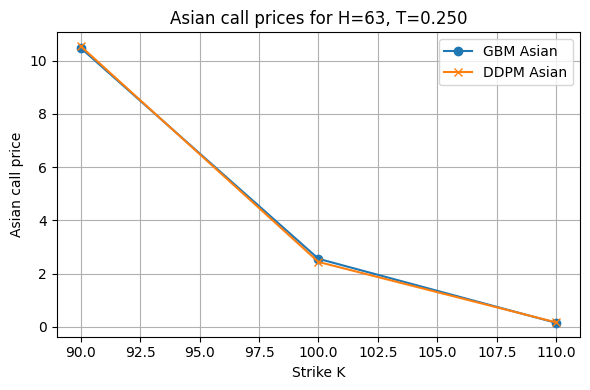

In [22]:
import matplotlib.pyplot as plt

H_plot = 63
df_plot = df_asian[df_asian["H_steps"] == H_plot].sort_values("K")

plt.figure(figsize=(6,4))
plt.plot(df_plot["K"], df_plot["gbm_asian_price"], marker="o", label="GBM Asian")
plt.plot(df_plot["K"], df_plot["ddpm_asian_price"], marker="x", label="DDPM Asian")
plt.xlabel("Strike K")
plt.ylabel("Asian call price")
plt.title(f"Asian call prices for H={H_plot}, T={H_plot * dt:.3f}")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
